In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from umap import UMAP
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("库加载完成")

/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


库加载完成


In [3]:
# 加载数据
psth_path = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/all_subjects_psth.npy'
unit_info_path = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/all_subjects_unit_info.pkl'

psth_data = np.load(psth_path, mmap_mode='r')
unit_info = pd.read_pickle(unit_info_path)

print(f"PSTH数据形状: {psth_data.shape}")
print(f"单元信息记录数: {len(unit_info)}")
print(f"\n单元信息列名: {unit_info.columns.tolist()}")

PSTH数据形状: (15652, 1072, 450)
单元信息记录数: 15652

单元信息列名: ['B_SI', 'F_SI', 'O_SI', 'UnitType', 'best_r_time1', 'best_r_time2', 'pos', 'reliability_basic', 'reliability_best', 'reliability_find_testset', 'snr', 'snrmax', 'session_id', 'date', 'subject', 'SesIdx', 'AREALABEL', 'Area', 'waveform', 'spikepos_1', 'spikepos_2']


In [4]:
# 计算所有图像的response
# 参考 compute_neuron_responses.py，使用best_r_time1和best_r_time2确定的时间窗口
n_neurons = psth_data.shape[0]
n_stimuli = psth_data.shape[1]
n_time = psth_data.shape[2]

best_r_time1 = unit_info['best_r_time1'].values
best_r_time2 = unit_info['best_r_time2'].values

# 初始化响应矩阵
neuron_responses = np.zeros((n_neurons, n_stimuli), dtype=np.float32)

print(f"计算神经元响应 (使用最佳时间窗口)...")
print(f"时间窗口范围: [{best_r_time1.min()}, {best_r_time1.max()}] -> [{best_r_time2.min()}, {best_r_time2.max()}]")

for neuron_idx in range(n_neurons):
    start_time = int(best_r_time1[neuron_idx])
    end_time = int(best_r_time2[neuron_idx])
    
    # 处理时间窗口越界情况
    if start_time < 0:
        start_time = 0
    if end_time > n_time:
        end_time = n_time
    if end_time <= start_time:
        mid_time = n_time // 2
        start_time = max(0, mid_time - 5)
        end_time = min(n_time, mid_time + 5)
    
    # 计算该神经元在时间窗口内的平均响应
    psth_neuron = psth_data[neuron_idx, :n_stimuli, start_time:end_time]
    neuron_responses[neuron_idx] = np.mean(psth_neuron, axis=1)

print(f"神经元响应形状: {neuron_responses.shape}")

# 检查是否有NaN
nan_count = np.sum(np.isnan(neuron_responses))
print(f"NaN值数量: {nan_count}")

计算神经元响应 (使用最佳时间窗口)...
时间窗口范围: [20, 200] -> [90, 390]
神经元响应形状: (15652, 1072)
NaN值数量: 0


In [5]:
# 分割数据：前1000张和后72张
responses_1000 = neuron_responses[:, :1000]
responses_72 = neuron_responses[:, 1000:]

# 每个 unit 对所有图片的响应平均 -> mean_firing_rate (n_neurons,)
mean_firing_rate = np.log10(neuron_responses.mean(axis=1))

In [5]:
# 前1000张：PCA降到30维，再用UMAP降到3维
print("处理前1000张图像...")

# PCA降维到30维
pca_1000 = PCA(n_components=30)
responses_pca_1000 = pca_1000.fit_transform(responses_1000)
print(f"PCA后形状: {responses_pca_1000.shape}")
print(f"PCA累计解释方差: {pca_1000.explained_variance_ratio_.sum():.4f}")

# UMAP降到3维
umap_1000 = UMAP(n_components=3, random_state=42, n_neighbors=15, min_dist=0.1)
responses_umap_1000 = umap_1000.fit_transform(responses_pca_1000)
print(f"UMAP后形状: {responses_umap_1000.shape}")

处理前1000张图像...
PCA后形状: (15652, 30)
PCA累计解释方差: 0.7373
UMAP后形状: (15652, 3)


In [21]:
import os
import networkx as nx
from tqdm import tqdm

THRESHOLDS = [103, 206, 409, 612]
OUT_DIR = '/media/ubuntu/sda/TrippleN/customize/mua'
os.makedirs(OUT_DIR, exist_ok=True)

unit_info_global = unit_info.reset_index(drop=True)
groups = unit_info_global.groupby('session_id').groups
spikepos1 = unit_info_global['spikepos_1'].values.astype(np.float64)
spikepos2 = unit_info_global['spikepos_2'].values.astype(np.float64)

def build_mua_for_session(global_indices, coords, threshold):
    n = len(global_indices)
    if n == 0:
        return []
    pos = coords
    dist = np.sqrt(((pos[:, None, :] - pos[None, :, :]) ** 2).sum(axis=2))
    adj = (dist <= threshold).astype(np.float64)
    np.fill_diagonal(adj, 0)
    G = nx.from_numpy_array(adj)
    cliques = list(nx.find_cliques(G))
    return [np.array(global_indices)[list(c)] for c in cliques]

for th in tqdm(THRESHOLDS, desc='resolution'):
    all_cliques = []
    all_sessions = []
    for sid, global_indices in groups.items():
        global_indices = np.array(global_indices)
        coords = np.column_stack([spikepos1[global_indices], spikepos2[global_indices]])
        cliques = build_mua_for_session(global_indices, coords, th)
        for c in cliques:
            all_cliques.append(c)
            all_sessions.append(sid)
    mua_resp_72 = np.array([np.mean(responses_72[c], axis=0) for c in all_cliques], dtype=np.float32)
    mua_resp_1000 = np.array([np.mean(responses_1000[c], axis=0) for c in all_cliques], dtype=np.float32)
    mua_unit_info = pd.DataFrame({'id': np.arange(len(all_cliques)), 'session_id': all_sessions})
    np.save(os.path.join(OUT_DIR, f'mua_responses_72_{th}.npy'), mua_resp_72)
    np.save(os.path.join(OUT_DIR, f'mua_responses_1000_{th}.npy'), mua_resp_1000)
    mua_unit_info.to_pickle(os.path.join(OUT_DIR, f'mua_unit_info_{th}.pkl'))
    print(f'threshold {th} um: n_mua={len(all_cliques)}, responses_72 {mua_resp_72.shape}, responses_1000 {mua_resp_1000.shape}')

sess_resp_72 = np.array([np.mean(responses_72[np.array(g)], axis=0) for g in groups.values()], dtype=np.float32)
sess_resp_1000 = np.array([np.mean(responses_1000[np.array(g)], axis=0) for g in groups.values()], dtype=np.float32)
sess_unit_info = pd.DataFrame({'id': np.arange(len(groups)), 'session_id': list(groups.keys())})
np.save(os.path.join(OUT_DIR, 'mua_responses_72_session.npy'), sess_resp_72)
np.save(os.path.join(OUT_DIR, 'mua_responses_1000_session.npy'), sess_resp_1000)
sess_unit_info.to_pickle(os.path.join(OUT_DIR, 'mua_unit_info_session.pkl'))
print(f'session: n={len(groups)}, responses_72 {sess_resp_72.shape}, responses_1000 {sess_resp_1000.shape}')

resolution:  25%|██▌       | 1/4 [00:00<00:01,  2.12it/s]

threshold 103 um: n_mua=7233, responses_72 (7233, 72), responses_1000 (7233, 1000)


resolution:  50%|█████     | 2/4 [00:02<00:02,  1.33s/it]

threshold 206 um: n_mua=11060, responses_72 (11060, 72), responses_1000 (11060, 1000)


resolution:  75%|███████▌  | 3/4 [00:07<00:03,  3.26s/it]

threshold 409 um: n_mua=7471, responses_72 (7471, 72), responses_1000 (7471, 1000)


resolution: 100%|██████████| 4/4 [00:17<00:00,  4.44s/it]

threshold 612 um: n_mua=5898, responses_72 (5898, 72), responses_1000 (5898, 1000)
session: n=51, responses_72 (51, 72), responses_1000 (51, 1000)


In [6]:
# 后72张：PCA降到15维，再用UMAP降到3维
print("处理后72张图像...")

# PCA降维到15维
pca_72 = PCA(n_components=20)
responses_pca_72 = pca_72.fit_transform(responses_72)
print(f"PCA后形状: {responses_pca_72.shape}")
print(f"PCA累计解释方差: {pca_72.explained_variance_ratio_.sum():.4f}")

# UMAP降到3维
umap_72 = UMAP(n_components=3, random_state=42, n_neighbors=10, min_dist=0.1)
responses_umap_72 = umap_72.fit_transform(responses_pca_72)
print(f"UMAP后形状: {responses_umap_72.shape}")

处理后72张图像...
PCA后形状: (15652, 20)
PCA累计解释方差: 0.8622
UMAP后形状: (15652, 3)


In [5]:
unit_info['Body_selectivity'] = (unit_info['B_SI'] > 0.3).astype(int)
unit_info['Face_selectivity'] = (unit_info['F_SI'] > 0.3).astype(int)
unit_info['Object_selectivity'] = (unit_info['O_SI'] > 0.3).astype(int)

n_selectivities = unit_info['Body_selectivity'] + unit_info['Face_selectivity'] + unit_info['Object_selectivity']
n_multi_selective = (n_selectivities >= 2).sum()
print(f"具有两个及以上选择性的神经元数量: {n_multi_selective} / {len(unit_info)} ({100*n_multi_selective/len(unit_info):.2f}%)")

具有两个及以上选择性的神经元数量: 684 / 15652 (4.37%)


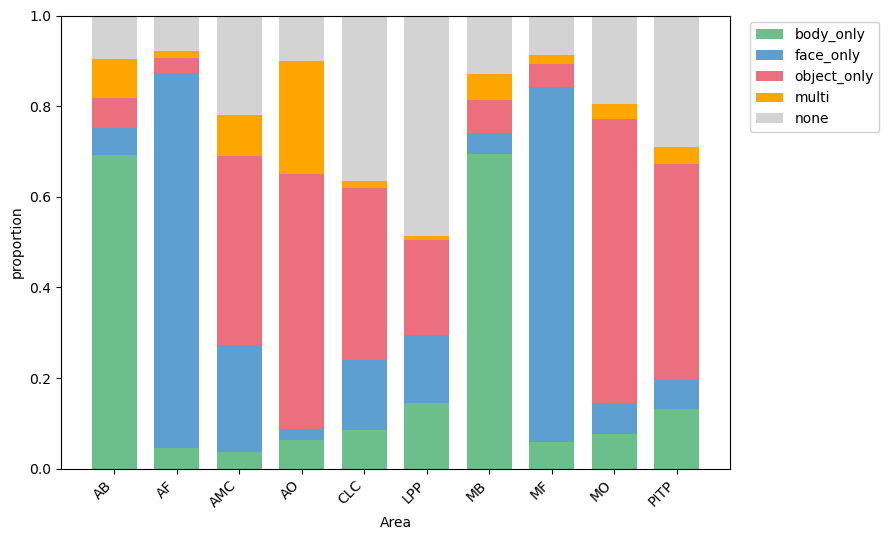

saved: /media/ubuntu/sda/TrippleN/customize/figures/selectivity_class_by_area_stacked_bar.pdf


In [9]:
OUT_DIR = '/media/ubuntu/sda/TrippleN/customize/figures'
B = unit_info["Body_selectivity"].to_numpy()
F = unit_info["Face_selectivity"].to_numpy()
O = unit_info["Object_selectivity"].to_numpy()
n_sel = B + F + O
sel_type = np.full(len(unit_info), "none", dtype=object)
sel_type[n_sel >= 2] = "multi"
sel_type[(n_sel == 1) & (B == 1)] = "body_only"
sel_type[(n_sel == 1) & (F == 1)] = "face_only"
sel_type[(n_sel == 1) & (O == 1)] = "object_only"
unit_info["selectivity_class"] = sel_type
order_types = ["body_only", "face_only", "object_only", "multi", "none"]
type_colors = {
    "body_only": "#6BBF8A",
    "face_only": "#5E9FD1",
    "object_only": "#EC6F7E",
    "multi": "orange",
    "none": "lightgray",
}

plot_df = unit_info.dropna(subset=["Area"]).copy()
counts = plot_df.groupby(["Area", "selectivity_class"]).size().unstack(fill_value=0)
counts = counts.reindex(columns=order_types, fill_value=0)
row_sum = counts.sum(axis=1).replace(0, np.nan)
props = counts.div(row_sum, axis=0).fillna(0)

fig_w = max(9, len(props) * 0.38)
fig, ax = plt.subplots(figsize=(fig_w, 5.5))
bottom = np.zeros(len(props))
x = np.arange(len(props))
for typ in order_types:
    vals = props[typ].to_numpy()
    ax.bar(x, vals, bottom=bottom, label=typ, color=type_colors[typ], width=0.72)
    bottom = bottom + vals
ax.set_xticks(x)
ax.set_xticklabels(props.index.astype(str), rotation=45, ha="right")
ax.set_ylabel("proportion")
ax.set_xlabel("Area")
ax.set_ylim(0, 1)
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left", framealpha=0.9)
fig.tight_layout()
out_pdf = OUT_DIR + "/selectivity_class_by_area_stacked_bar.pdf"
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()
print("saved:", out_pdf)

In [8]:
# 绘制后72张的3D UMAP图（用 Plotly 分别绘制 6 个可交互 3D 图）
x2, y2, z2 = responses_umap_72[:, 0], responses_umap_72[:, 1], responses_umap_72[:, 2]
unit_types = unit_info['UnitType'].values
subjects = unit_info['subject'].values
areas = unit_info['AREALABEL'].values
colors_tab10 = px.colors.qualitative.Set1
colors_set2 = px.colors.qualitative.Set2

scene_white = dict(
    xaxis_title='UMAP 1', yaxis_title='UMAP 2', zaxis_title='UMAP 3',
    bgcolor='white',
    xaxis=dict(backgroundcolor='white', showgrid=False, zeroline=False),
    yaxis=dict(backgroundcolor='white', showgrid=False, zeroline=False),
    zaxis=dict(backgroundcolor='white', showgrid=False, zeroline=False),
    camera=dict(
        eye=dict(x=-1, y=1.6, z=1.3),
        center=dict(x=0, y=0, z=0),
        up=dict(x=0, y=0, z=1)
    )
)
layout_white = dict(paper_bgcolor='white', plot_bgcolor='white', margin=dict(l=0, r=0, b=0, t=40))

fig_ut = go.Figure()
for i, utype in enumerate(np.unique(unit_types)):
    mask = unit_types == utype
    fig_ut.add_trace(go.Scatter3d(
        x=x2[mask], y=y2[mask], z=z2[mask],
        mode='markers', name=str(utype),
        marker=dict(size=1, opacity=1, color=['#8AB07C','#5E9FD1','#EC6F7E'][i])
    ))
fig_ut.update_layout(title='Last 72 Images - By UnitType', scene=scene_white, **layout_white)
fig_ut.show()

fig_sub = go.Figure()
unique_subjects = np.unique(subjects)[:10]
for i, subj in enumerate(unique_subjects):
    mask = subjects == subj
    fig_sub.add_trace(go.Scatter3d(
        x=x2[mask], y=y2[mask], z=z2[mask],
        mode='markers', name=str(subj),
        marker=dict(size=1, opacity=1, color=colors_tab10[i % len(colors_tab10)])
    ))
fig_sub.update_layout(title='Last 72 Images - By Subject (Top 10)', scene=scene_white, **layout_white)
fig_sub.show()

if 'B_SI' in unit_info.columns:
    b_si = unit_info['B_SI'].values
    fig_bsi = go.Figure(data=[go.Scatter3d(
        x=x2, y=y2, z=z2,
        mode='markers',
        marker=dict(size=1, opacity=1, color=b_si, colorscale='RdBu_r', colorbar=dict(title='B_SI'))
    )])
    fig_bsi.update_layout(title='Last 72 Images - By B_SI', scene=scene_white, **layout_white)
    fig_bsi.show()

if 'F_SI' in unit_info.columns:
    f_si = unit_info['F_SI'].values
    fig_fsi = go.Figure(data=[go.Scatter3d(
        x=x2, y=y2, z=z2,
        mode='markers',
        marker=dict(size=1, opacity=1, color=f_si, colorscale='RdBu_r', colorbar=dict(title='F_SI'))
    )])
    fig_fsi.update_layout(title='Last 72 Images - By F_SI', scene=scene_white, **layout_white)
    fig_fsi.show()

if 'O_SI' in unit_info.columns:
    o_si = unit_info['O_SI'].values
    fig_osi = go.Figure(data=[go.Scatter3d(
        x=x2, y=y2, z=z2,
        mode='markers',
        marker=dict(size=1, opacity=1, color=o_si, colorscale='RdBu_r', colorbar=dict(title='O_SI'))
    )])
    fig_osi.update_layout(title='Last 72 Images - By O_SI', scene=scene_white, **layout_white)
    fig_osi.show()

fig_mfr72 = go.Figure(data=[go.Scatter3d(
    x=x2, y=y2, z=z2,
    mode='markers',
    marker=dict(size=1, opacity=1, color=mean_firing_rate, colorscale='RdBu_r', colorbar=dict(title='mean_firing_rate'))
)])
fig_mfr72.update_layout(title='Last 72 Images - By mean_firing_rate', scene=scene_white, **layout_white)
fig_mfr72.show()

if all(c in unit_info.columns for c in ['Body_selectivity', 'Face_selectivity', 'Object_selectivity']):
    color_sel_none = 'lightgray'
    color_sel_multi = 'orange'
    color_sel_body = '#8AB07C'
    color_sel_face = '#5E9FD1'
    color_sel_object = '#EC6F7E'
    B = unit_info['Body_selectivity'].values
    F = unit_info['Face_selectivity'].values
    O = unit_info['Object_selectivity'].values
    n_sel = B + F + O
    mask_none = n_sel == 0
    mask_multi = n_sel >= 2
    mask_body = (B == 1) & (F == 0) & (O == 0)
    mask_face = (F == 1) & (B == 0) & (O == 0)
    mask_object = (O == 1) & (B == 0) & (F == 0)
    fig_sel = go.Figure()
    fig_sel.add_trace(go.Scatter3d(x=x2[mask_none], y=y2[mask_none], z=z2[mask_none], mode='markers', name='无选择性', marker=dict(size=1, opacity=1, color=color_sel_none)))
    fig_sel.add_trace(go.Scatter3d(x=x2[mask_multi], y=y2[mask_multi], z=z2[mask_multi], mode='markers', name='2种及以上', marker=dict(size=1, opacity=1, color=color_sel_multi)))
    if mask_body.any():
        fig_sel.add_trace(go.Scatter3d(x=x2[mask_body], y=y2[mask_body], z=z2[mask_body], mode='markers', name='仅Body', marker=dict(size=1, opacity=1, color=color_sel_body)))
    if mask_face.any():
        fig_sel.add_trace(go.Scatter3d(x=x2[mask_face], y=y2[mask_face], z=z2[mask_face], mode='markers', name='仅Face', marker=dict(size=1, opacity=1, color=color_sel_face)))
    if mask_object.any():
        fig_sel.add_trace(go.Scatter3d(x=x2[mask_object], y=y2[mask_object], z=z2[mask_object], mode='markers', name='仅Object', marker=dict(size=1, opacity=1, color=color_sel_object)))
    fig_sel.update_layout(title='Last 72 Images - Selectivity (Body/Face/Object)', scene=scene_white, **layout_white)
    fig_sel.show()

import os
out_dir = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/figure'
os.makedirs(out_dir, exist_ok=True)
fig_ut.write_html(os.path.join(out_dir, 'umap3d_last_72_unittype.html'))
fig_sub.write_html(os.path.join(out_dir, 'umap3d_last_72_subject.html'))
if 'B_SI' in unit_info.columns:
    fig_bsi.write_html(os.path.join(out_dir, 'umap3d_last_72_B_SI.html'))
if 'F_SI' in unit_info.columns:
    fig_fsi.write_html(os.path.join(out_dir, 'umap3d_last_72_F_SI.html'))
if 'O_SI' in unit_info.columns:
    fig_osi.write_html(os.path.join(out_dir, 'umap3d_last_72_O_SI.html'))
fig_mfr72.write_html(os.path.join(out_dir, 'umap3d_last_72_mean_firing_rate.html'))
if all(c in unit_info.columns for c in ['Body_selectivity', 'Face_selectivity', 'Object_selectivity']):
    fig_sel.write_html(os.path.join(out_dir, 'umap3d_last_72_selectivity.html'))
print(f"已保存至 {out_dir}")


已保存至 /media/ubuntu/sda/TrippleN/customize/aggregate_response/figure


In [16]:
n_bins = 10
bin_edges = np.percentile(mean_firing_rate, np.linspace(0, 100, n_bins + 1))
bin_labels = [f'Bin{i+1}' for i in range(n_bins)]
bin_idx = pd.cut(mean_firing_rate, bins=bin_edges, labels=False, include_lowest=True).astype(int)

B = unit_info['Body_selectivity'].values
F = unit_info['Face_selectivity'].values
O = unit_info['Object_selectivity'].values
n_sel = B + F + O
sel_cat = np.where(n_sel == 0, '无选择性',
          np.where(n_sel >= 2, '2种及以上',
          np.where((B==1)&(F==0)&(O==0), '仅Body',
          np.where((F==1)&(B==0)&(O==0), '仅Face', '仅Object'))))
unit_types = unit_info['UnitType'].values

sel_order = ['无选择性', '仅Body', '仅Face', '仅Object', '2种及以上']
ut_order = np.unique(unit_types)

pct_sel = np.zeros((n_bins, len(sel_order)))
pct_ut = np.zeros((n_bins, len(ut_order)))
for i in range(n_bins):
    mask = bin_idx == i
    n_i = mask.sum()
    if n_i > 0:
        for j, c in enumerate(sel_order):
            pct_sel[i, j] = 100 * (sel_cat[mask] == c).sum() / n_i
        for j, c in enumerate(ut_order):
            pct_ut[i, j] = 100 * (unit_types[mask] == c).sum() / n_i

bar_layout = dict(
    paper_bgcolor='white', plot_bgcolor='white',
    xaxis=dict(showline=True, linewidth=1, linecolor='black', mirror=True, showgrid=False, title='mean_firing_rate bin'),
    yaxis=dict(showline=True, linewidth=1, linecolor='black', mirror=True, showgrid=True, title='百分比 (%)')
)

fig_sel_bar = go.Figure()
colors_sel = ['lightgray', '#8AB07C', '#5E9FD1', '#EC6F7E', 'orange']
for j, c in enumerate(sel_order):
    fig_sel_bar.add_trace(go.Bar(name=c, x=bin_labels, y=pct_sel[:, j], marker_color=colors_sel[j]))
fig_sel_bar.update_layout(barmode='stack', title='Selectivity by mean_firing_rate', **bar_layout)
fig_sel_bar.show()

fig_ut_bar = go.Figure()
colors_ut = ['#8AB07C', '#5E9FD1', '#EC6F7E']
for j, c in enumerate(ut_order):
    fig_ut_bar.add_trace(go.Bar(name=str(c), x=bin_labels, y=pct_ut[:, j], marker_color=colors_ut[j % len(colors_ut)]))
fig_ut_bar.update_layout(barmode='stack', title='UnitType by mean_firing_rate', **bar_layout)
fig_ut_bar.show()

out_dir_pdf = '/media/ubuntu/sda/TrippleN/customize/figures'
import os
os.makedirs(out_dir_pdf, exist_ok=True)
fig_sel_bar.write_image(os.path.join(out_dir_pdf, 'stacked_bar_selectivity.pdf'))
fig_ut_bar.write_image(os.path.join(out_dir_pdf, 'stacked_bar_unittype.pdf'))
print(f"已保存PDF至 {out_dir_pdf}")

已保存PDF至 /media/ubuntu/sda/TrippleN/customize/figures


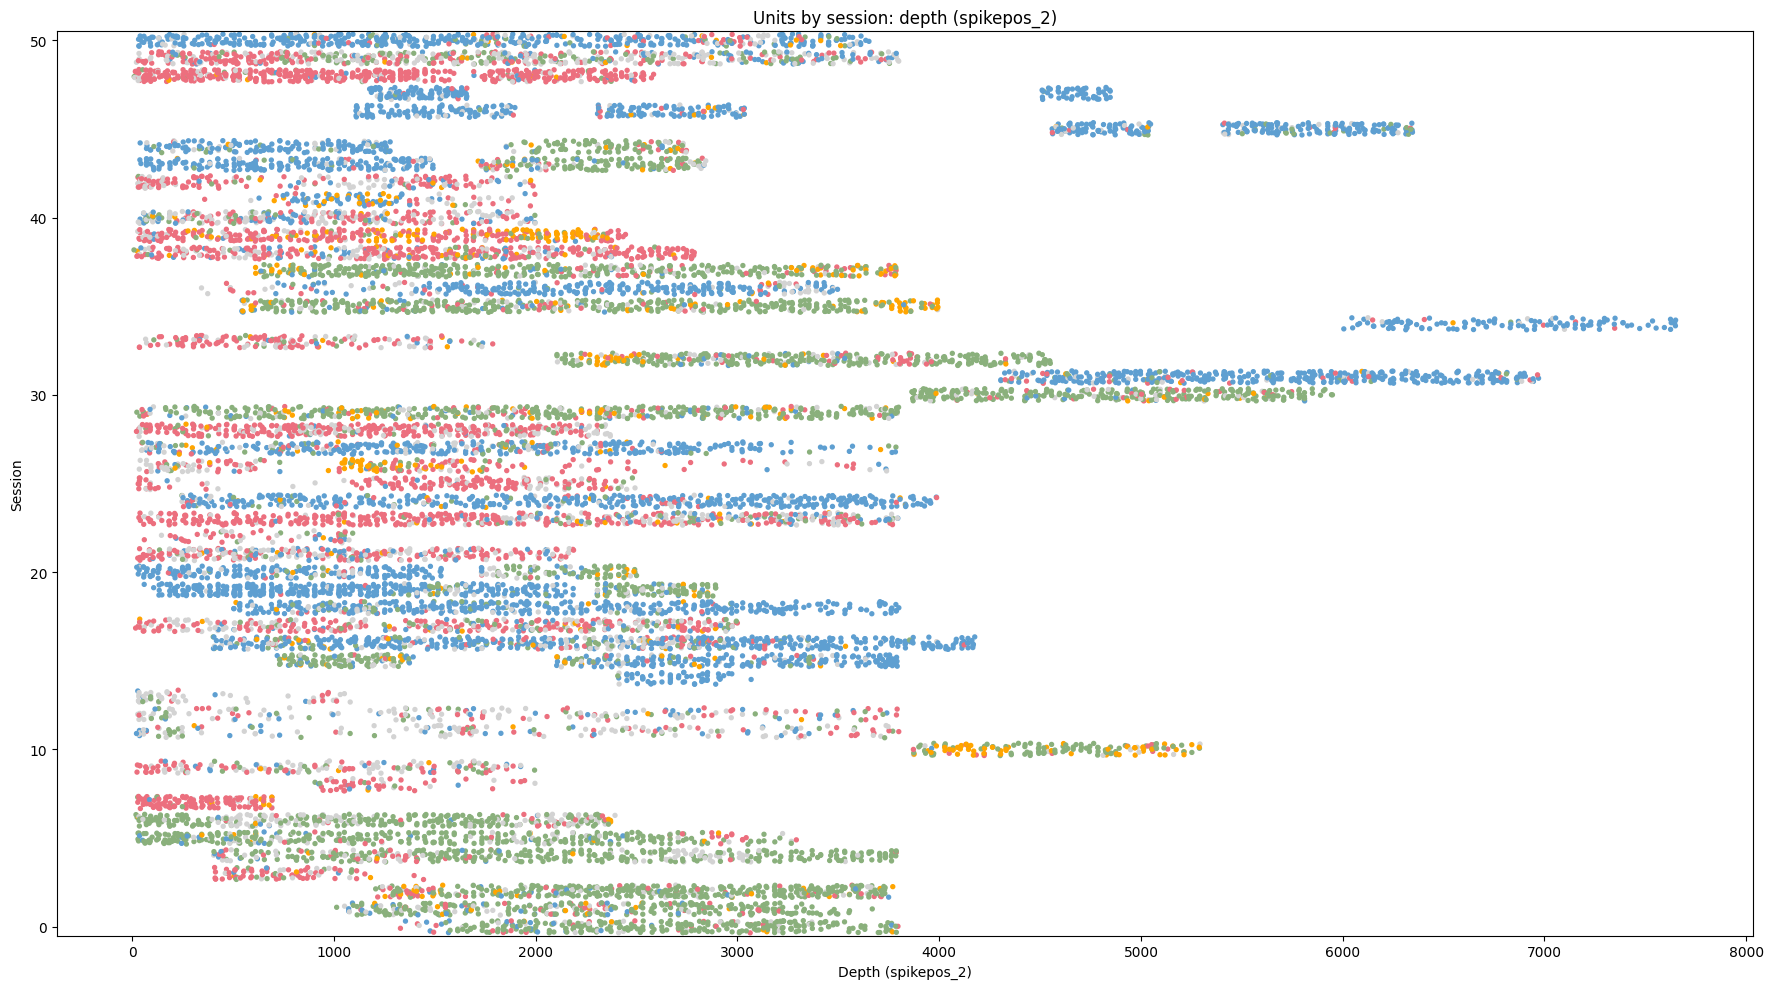

In [16]:
depth_col = 'spikepos_2'
B = unit_info['Body_selectivity'].values
F = unit_info['Face_selectivity'].values
O = unit_info['Object_selectivity'].values
n_sel = B + F + O
mask_none = n_sel == 0
mask_multi = n_sel >= 2
mask_body = (B == 1) & (F == 0) & (O == 0)
mask_face = (F == 1) & (B == 0) & (O == 0)
mask_object = (O == 1) & (B == 0) & (F == 0)
unit_colors = np.array(['lightgray'] * len(unit_info))
unit_colors[mask_multi] = 'orange'
unit_colors[mask_body] = '#8AB07C'
unit_colors[mask_face] = '#5E9FD1'
unit_colors[mask_object] = '#EC6F7E'
sessions = sorted(unit_info['session_id'].unique())
n_sessions = len(sessions)
session_to_idx = {sid: i for i, sid in enumerate(sessions)}
depth_all = unit_info[depth_col].values
colors_all = unit_colors
y_base = np.array([session_to_idx[sid] for sid in unit_info['session_id'].values])
rs = np.random.RandomState(42)
y_jitter = rs.uniform(-0.35, 0.35, size=len(unit_info))
y_all = y_base + y_jitter
fig, ax = plt.subplots(1, 1, figsize=(max(4, n_sessions * 0.35), 10))
ax.scatter(depth_all, y_all, c=colors_all, s=8, alpha=1)
ax.set_xlabel('Depth (spikepos_2)')
ax.set_ylabel('Session')
ax.set_ylim(-0.5, n_sessions - 0.5)
ax.set_title('Units by session: depth (spikepos_2)')
plt.tight_layout()
out_dir_pdf = '/media/ubuntu/sda/TrippleN/customize/figures'
os.makedirs(out_dir_pdf, exist_ok=True)
plt.savefig(os.path.join(out_dir_pdf, 'units_by_session_depth.pdf'), bbox_inches='tight')
plt.show()